Hurst exponent: 0.572942871466669
Hurst exponent: 0.5915859326693826


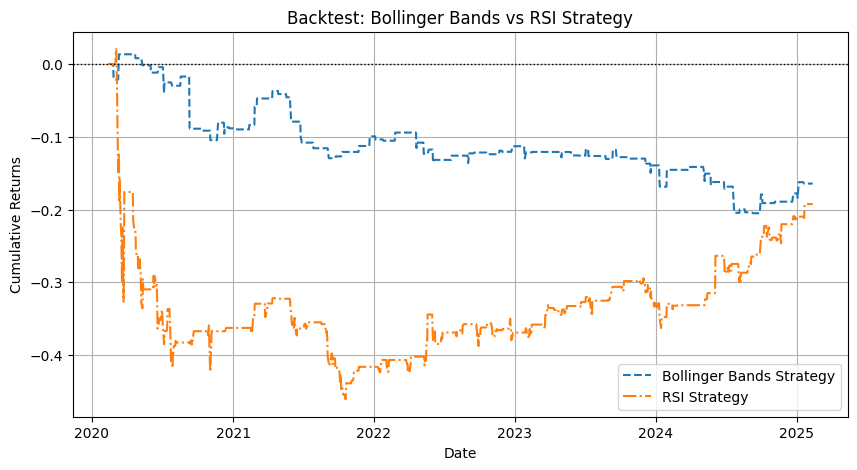

Bollinger Bands Strategy Return: -0.1643371993334639
RSI Strategy Return: -0.19248797144274443


In [3]:
import pandas as pd
import numpy as np
from hurst import compute_Hc
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Load Data
df = pd.read_csv("/home/qa/runtime/data/analysis_out/garch/reliance.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

def compute_hurst_exponent(ts, max_lag=100):
    """Compute the Hurst exponent using the rescaled range (R/S) method."""
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    hurst_exp = np.polyfit(np.log(lags), np.log(tau), 1)[0]
    return hurst_exp

# First-order differencing
df['Close_diff'] = df['Close'].diff().dropna()
# Log returns
df['Close_log'] = np.log(df['Close'])
df['Close_log_diff'] = df['Close_log'].diff().dropna()

# ADF Tests
adf_p_value_diff = adfuller(df['Close_diff'].dropna())[1]
adf_p_value_log_diff = adfuller(df['Close_log_diff'].dropna())[1]

# Hurst Exponent Computation
H1, c1, data1 = compute_Hc(df['Close_diff'].dropna().values, kind='change', simplified=True)
print(f"Hurst exponent: {H1}")
H2, c2, data2= compute_Hc(df['Close_log_diff'].dropna().values, kind='change', simplified=True)
print(f"Hurst exponent: {H2}")
# hurst_exp_diff = compute_hurst_exponent(df['Close_diff'].dropna().values)
# hurst_exp_log_diff = compute_hurst_exponent(df['Close_log_diff'].dropna().values)

def bollinger_band_strategy(df, window=10, num_std=2):
    df['Rolling_Mean'] = df['Close'].rolling(window=window).mean()
    df['Rolling_Std'] = df['Close'].rolling(window=window).std()
    df['Upper_Band'] = df['Rolling_Mean'] + (num_std * df['Rolling_Std'])
    df['Lower_Band'] = df['Rolling_Mean'] - (num_std * df['Rolling_Std'])
    df['Signal'] = 0
    df.loc[df['Close'] < df['Lower_Band'], 'Signal'] = 1
    df.loc[df['Close'] > df['Upper_Band'], 'Signal'] = -1
    return df

def rsi_strategy(df, window=14, overbought=70, oversold=30):
    delta = df['Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['Signal'] = 0
    df.loc[df['RSI'] < oversold, 'Signal'] = 1
    df.loc[df['RSI'] > overbought, 'Signal'] = -1
    return df

def backtest(df):
    df['Daily_Return'] = df['Close'].pct_change()
    df['Strategy_Return'] = df['Signal'].shift(1) * df['Daily_Return']
    cumulative_return = (1 + df['Strategy_Return']).cumprod() - 1
    return cumulative_return

df_bb = bollinger_band_strategy(df.copy(), window=10, num_std=2)
df_rsi = rsi_strategy(df.copy(), window=14, overbought=70, oversold=30)

bb_returns = backtest(df_bb)
rsi_returns = backtest(df_rsi)

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], bb_returns, label="Bollinger Bands Strategy", linestyle="--")
plt.plot(df['Date'], rsi_returns, label="RSI Strategy", linestyle="-.")
plt.axhline(y=0, color="black", linewidth=1, linestyle="dotted")
plt.legend()
plt.title("Backtest: Bollinger Bands vs RSI Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

# Display final returns
print("Bollinger Bands Strategy Return:", bb_returns.iloc[-1])
print("RSI Strategy Return:", rsi_returns.iloc[-1])
